In [78]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/transactions.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 transactions:")
display(df.head())

Dataset shape: (500000, 13)

Columns:
['transaction_id', 'timestamp', 'merchant_id', 'amount', 'device_id', 'ip_address', 'card_bin', 'success', 'is_attack', 'hour', 'day_of_week', 'is_low_value', 'is_failed']

First 5 transactions:


,transaction_id,timestamp,merchant_id,amount,device_id,ip_address,card_bin,success,is_attack,hour,day_of_week,is_low_value,is_failed
0,TXN_N_0300360,2026-01-01 00:00:04,M0006,153.99,DEV_N_12184,103.241.246.44,378282,1,0,0,3,0,0
1,TXN_N_0138043,2026-01-01 00:00:08,M0003,98.47,DEV_N_19198,103.242.129.10,400000,1,0,0,3,0,0
2,TXN_N_0295072,2026-01-01 00:00:16,M0096,300.25,DEV_N_14645,103.123.254.234,520082,1,0,0,3,0,0
3,TXN_N_0143511,2026-01-01 00:00:21,M0038,481.57,DEV_N_09820,103.250.34.47,510510,1,0,0,3,0,0
4,TXN_N_0251316,2026-01-01 00:00:22,M0082,369.11,DEV_N_02966,103.228.166.64,491748,1,0,0,3,0,0


In [79]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/transactions.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 transactions:")
display(df.head())

Dataset shape: (500000, 13)

Columns:
['transaction_id', 'timestamp', 'merchant_id', 'amount', 'device_id', 'ip_address', 'card_bin', 'success', 'is_attack', 'hour', 'day_of_week', 'is_low_value', 'is_failed']

First 5 transactions:


,transaction_id,timestamp,merchant_id,amount,device_id,ip_address,card_bin,success,is_attack,hour,day_of_week,is_low_value,is_failed
0,TXN_N_0300360,2026-01-01 00:00:04,M0006,153.99,DEV_N_12184,103.241.246.44,378282,1,0,0,3,0,0
1,TXN_N_0138043,2026-01-01 00:00:08,M0003,98.47,DEV_N_19198,103.242.129.10,400000,1,0,0,3,0,0
2,TXN_N_0295072,2026-01-01 00:00:16,M0096,300.25,DEV_N_14645,103.123.254.234,520082,1,0,0,3,0,0
3,TXN_N_0143511,2026-01-01 00:00:21,M0038,481.57,DEV_N_09820,103.250.34.47,510510,1,0,0,3,0,0
4,TXN_N_0251316,2026-01-01 00:00:22,M0082,369.11,DEV_N_02966,103.228.166.64,491748,1,0,0,3,0,0


In [80]:
print("Normal transactions:", (df["is_attack"] == 0).sum())
print("Attack transactions:", (df["is_attack"] == 1).sum())

print("\nSuccess rate by transaction type:")
print(
    df.groupby("is_attack")["success"]
      .mean()
      .rename({
          0: "Normal",
          1: "Attack"
      })
)

print("\nLow-value transactions:")
print(df["is_low_value"].sum())

print("\nLow-value rate by transaction type:")
print(
    df.groupby("is_attack")["is_low_value"]
      .mean()
      .rename({
          0: "Normal",
          1: "Attack"
      })
)

Normal transactions: 450000
Attack transactions: 50000

Success rate by transaction type:
is_attack
Normal    0.930031
Attack    0.183340
Name: success, dtype: float64

Low-value transactions:
86034

Low-value rate by transaction type:
is_attack
Normal    0.080076
Attack    1.000000
Name: is_low_value, dtype: float64


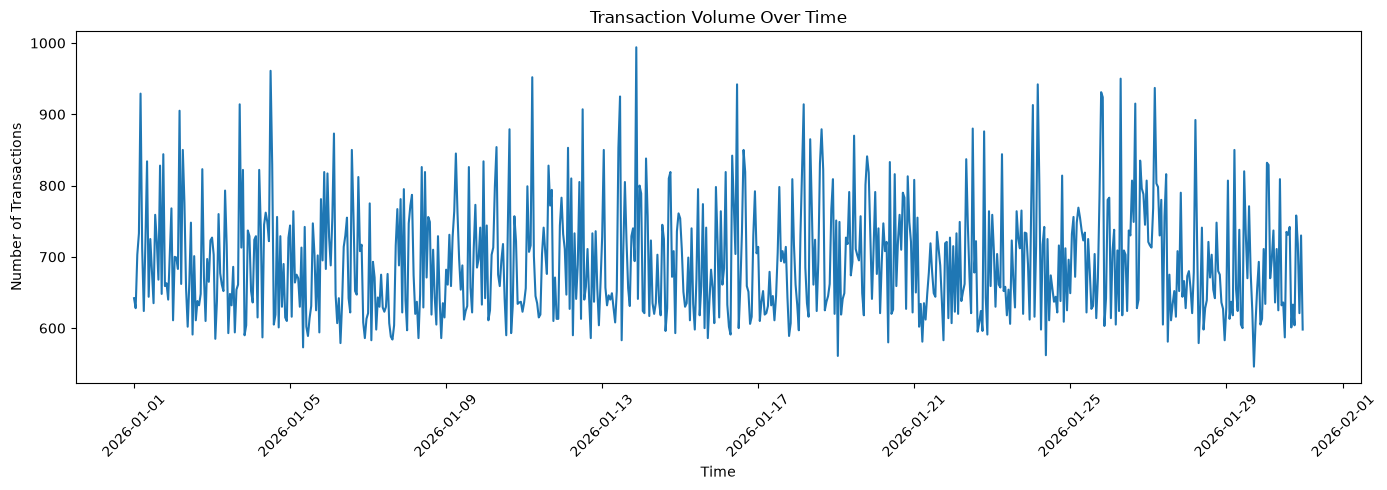

In [81]:
import matplotlib.pyplot as plt

df["timestamp"] = pd.to_datetime(df["timestamp"])

transactions_per_hour = (
    df.set_index("timestamp")
      .resample("1h")
      .size()
)

plt.figure(figsize=(14, 5))
plt.plot(transactions_per_hour)
plt.title("Transaction Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
df["minute"] = df["timestamp"].dt.floor("min")

minute_stats = (
    df.groupby("minute")
      .agg(
          transaction_count=("transaction_id", "count"),
          failed_count=("is_failed", "sum"),
          low_value_count=("is_low_value", "sum"),
          unique_devices=("device_id", "nunique"),
          unique_ips=("ip_address", "nunique"),
          unique_bins=("card_bin", "nunique"),
          attack_count=("is_attack", "sum")
      )
      .reset_index()
)

minute_stats["failure_rate"] = (
    minute_stats["failed_count"] /
    minute_stats["transaction_count"]
)

minute_stats["low_value_rate"] = (
    minute_stats["low_value_count"] /
    minute_stats["transaction_count"]
)

display(minute_stats.head())

,minute,transaction_count,failed_count,low_value_count,unique_devices,unique_ips,unique_bins,attack_count,failure_rate,low_value_rate
0,2026-01-01 00:00:00,13,1,0,13,13,9,0,0.076923,0.000000
1,2026-01-01 00:01:00,14,2,0,14,14,8,0,0.142857,0.000000
2,2026-01-01 00:02:00,9,1,1,9,9,6,0,0.111111,0.111111
3,2026-01-01 00:03:00,14,1,2,14,14,9,0,0.071429,0.142857
4,2026-01-01 00:04:00,14,4,0,14,14,7,0,0.285714,0.000000


In [83]:
comparison = (
    minute_stats.groupby(minute_stats["attack_count"] > 0)
    .agg(
        avg_transactions=("transaction_count", "mean"),
        avg_failures=("failure_rate", "mean"),
        avg_low_value=("low_value_rate", "mean"),
        avg_devices=("unique_devices", "mean"),
        avg_ips=("unique_ips", "mean"),
        avg_bins=("unique_bins", "mean"),
        minutes=("transaction_count", "count")
    )
    .rename(index={
        False: "Normal minutes",
        True: "Attack minutes"
    })
)

display(comparison)

,avg_transactions,avg_failures,avg_low_value,avg_devices,avg_ips,avg_bins,minutes
attack_count,,,,,,,
Normal minutes,10.415230,0.070144,0.080333,10.412523,10.404006,6.958769,37690
Attack minutes,19.500907,0.391748,0.478259,11.500907,11.495281,9.725771,5510


In [84]:
signal_strength = (
    minute_stats.groupby(minute_stats["attack_count"] > 0)
    [
        [
            "transaction_count",
            "failure_rate",
            "low_value_rate",
            "unique_devices",
            "unique_ips",
            "unique_bins"
        ]
    ]
    .mean()
)

signal_strength.index = [
    "Normal minutes",
    "Attack minutes"
]

display(signal_strength)

,transaction_count,failure_rate,low_value_rate,unique_devices,unique_ips,unique_bins
Normal minutes,10.415230,0.070144,0.080333,10.412523,10.404006,6.958769
Attack minutes,19.500907,0.391748,0.478259,11.500907,11.495281,9.725771


In [85]:
# ============================================================
# CARD-TESTING SENTINEL - RISK SCORE
# ============================================================

# Normalize each signal against its observed distribution

def percentile_score(series):
    return series.rank(pct=True) * 100


minute_stats["volume_score"] = percentile_score(
    minute_stats["transaction_count"]
)

minute_stats["failure_score"] = percentile_score(
    minute_stats["failure_rate"]
)

minute_stats["low_value_score"] = percentile_score(
    minute_stats["low_value_rate"]
)

minute_stats["device_score"] = percentile_score(
    minute_stats["unique_devices"]
)

minute_stats["ip_score"] = percentile_score(
    minute_stats["unique_ips"]
)

minute_stats["bin_score"] = percentile_score(
    minute_stats["unique_bins"]
)


# Weighted risk score
minute_stats["risk_score"] = (
    0.25 * minute_stats["volume_score"]
    + 0.30 * minute_stats["failure_score"]
    + 0.25 * minute_stats["low_value_score"]
    + 0.10 * minute_stats["device_score"]
    + 0.05 * minute_stats["ip_score"]
    + 0.05 * minute_stats["bin_score"]
)


# Display highest-risk minutes
top_risk = minute_stats.sort_values(
    "risk_score",
    ascending=False
).head(20)

display(
    top_risk[
        [
            "minute",
            "transaction_count",
            "failure_rate",
            "low_value_rate",
            "unique_devices",
            "unique_ips",
            "unique_bins",
            "risk_score",
            "attack_count"
        ]
    ]
)

,minute,transaction_count,failure_rate,low_value_rate,unique_devices,unique_ips,unique_bins,risk_score,attack_count
250,2026-01-01 04:10:00,45,0.600000,0.711111,18,18,14,99.144444,30
19762,2026-01-14 17:22:00,43,0.627907,0.627907,18,18,14,98.881887,27
10777,2026-01-08 11:37:00,66,0.712121,0.787879,16,16,11,98.863021,52
33216,2026-01-24 01:36:00,51,0.647059,0.745098,16,16,16,98.848669,37
5763,2026-01-05 00:03:00,45,0.688889,0.711111,16,16,14,98.817361,31
12365,2026-01-09 14:05:00,50,0.620000,0.740000,16,16,14,98.754398,35
18588,2026-01-13 21:48:00,57,0.649123,0.789474,16,16,11,98.749016,43
16054,2026-01-12 03:34:00,49,0.530612,0.673469,18,18,16,98.663600,33
11929,2026-01-09 06:49:00,41,0.536585,0.634146,19,19,14,98.579398,24
1851,2026-01-02 06:51:00,38,0.578947,0.605263,18,18,15,98.528877,22


In [86]:
# ============================================================
# TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

minute_stats = minute_stats.sort_values("minute").reset_index(drop=True)

n = len(minute_stats)

train_end = int(n * 0.60)
validation_end = int(n * 0.80)

train_data = minute_stats.iloc[:train_end].copy()
validation_data = minute_stats.iloc[train_end:validation_end].copy()
test_data = minute_stats.iloc[validation_end:].copy()

print("Total minutes      :", len(minute_stats))
print("Training minutes   :", len(train_data))
print("Validation minutes :", len(validation_data))
print("Held-out test      :", len(test_data))

print("\nAttack minutes:")
print("Training   :", (train_data["attack_count"] > 0).sum())
print("Validation :", (validation_data["attack_count"] > 0).sum())
print("Test       :", (test_data["attack_count"] > 0).sum())

Total minutes      : 43200
Training minutes   : 25920
Validation minutes : 8640
Held-out test      : 8640

Attack minutes:
Training   : 3178
Validation : 1131
Test       : 1201


In [87]:
# ============================================================
# LEAKAGE-FREE RISK SCORING
# Baselines are learned ONLY from training data
# ============================================================

features = [
    "transaction_count",
    "failure_rate",
    "low_value_rate",
    "unique_devices",
    "unique_ips",
    "unique_bins"
]

def train_percentile_score(train_series, values):
    """
    Convert values to percentile scores using ONLY
    the training distribution.
    """
    sorted_values = np.sort(train_series.dropna().values)

    positions = np.searchsorted(
        sorted_values,
        values,
        side="right"
    )

    return (positions / len(sorted_values)) * 100


# Calculate scores using TRAINING data only
for feature in features:
    minute_stats[f"{feature}_score"] = train_percentile_score(
        train_data[feature],
        minute_stats[feature]
    )


# Weighted Sentinel risk score
minute_stats["risk_score"] = (
    0.25 * minute_stats["transaction_count_score"]
    + 0.30 * minute_stats["failure_rate_score"]
    + 0.25 * minute_stats["low_value_rate_score"]
    + 0.10 * minute_stats["unique_devices_score"]
    + 0.05 * minute_stats["unique_ips_score"]
    + 0.05 * minute_stats["unique_bins_score"]
)


# Re-create the three datasets with the new leakage-free score
train_data = minute_stats.iloc[:train_end].copy()
validation_data = minute_stats.iloc[
    train_end:validation_end
].copy()
test_data = minute_stats.iloc[
    validation_end:
].copy()


print("Leakage-free risk score created.")

print("\nTraining risk score:")
print(train_data["risk_score"].describe())

print("\nValidation risk score:")
print(validation_data["risk_score"].describe())

print("\nHeld-out test risk score:")
print(test_data["risk_score"].describe())

Leakage-free risk score created.

Training risk score:
count    25920.000000
mean        56.787919
std         16.762499
min         22.138696
25%         45.146412
50%         56.274113
75%         66.376157
max         99.228202
Name: risk_score, dtype: float64

Validation risk score:
count    8640.000000
mean       56.958980
std        16.867234
min        22.138696
25%        45.293596
50%        56.274113
75%        66.625772
max        99.067901
Name: risk_score, dtype: float64

Held-out test risk score:
count    8640.000000
mean       57.279006
std        17.051256
min        22.138696
25%        45.293596
50%        56.586227
75%        67.306906
max        98.627122
Name: risk_score, dtype: float64


In [88]:
from sklearn.metrics import precision_score, recall_score, f1_score

validation = validation_data.copy()

validation["actual_attack"] = (
    validation["attack_count"] > 0
).astype(int)

results = []

# Test thresholds from 50 to 95
for threshold in np.arange(50, 96, 1):

    validation["predicted_attack"] = (
        validation["risk_score"] >= threshold
    ).astype(int)

    precision = precision_score(
        validation["actual_attack"],
        validation["predicted_attack"],
        zero_division=0
    )

    recall = recall_score(
        validation["actual_attack"],
        validation["predicted_attack"],
        zero_division=0
    )

    f1 = f1_score(
        validation["actual_attack"],
        validation["predicted_attack"],
        zero_division=0
    )

    false_positives = (
        (validation["actual_attack"] == 0) &
        (validation["predicted_attack"] == 1)
    ).sum()

    false_negatives = (
        (validation["actual_attack"] == 1) &
        (validation["predicted_attack"] == 0)
    ).sum()

    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": false_positives,
        "false_negatives": false_negatives
    })

threshold_results = pd.DataFrame(results)

display(
    threshold_results.sort_values(
        "f1",
        ascending=False
    ).head(10)
)

,threshold,precision,recall,f1,false_positives,false_negatives
29,79,0.915354,0.822281,0.866325,86,201
28,78,0.892120,0.840849,0.865726,115,180
27,77,0.863758,0.857648,0.860692,153,161
30,80,0.927254,0.800177,0.859041,71,226
26,76,0.841567,0.873563,0.857267,186,143
31,81,0.941489,0.782493,0.854660,55,246
32,82,0.976852,0.746242,0.846115,20,287
25,75,0.806608,0.885057,0.844013,240,130
24,74,0.779061,0.894783,0.832922,287,119
33,83,0.980815,0.723254,0.832570,16,313


In [89]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ============================================================
# FINAL HELD-OUT TEST
# Threshold was selected using validation data only.
# ============================================================

FINAL_THRESHOLD = 79

test = test_data.copy()

test["actual_attack"] = (
    test["attack_count"] > 0
).astype(int)

test["predicted_attack"] = (
    test["risk_score"] >= FINAL_THRESHOLD
).astype(int)


# Metrics
precision = precision_score(
    test["actual_attack"],
    test["predicted_attack"],
    zero_division=0
)

recall = recall_score(
    test["actual_attack"],
    test["predicted_attack"],
    zero_division=0
)

f1 = f1_score(
    test["actual_attack"],
    test["predicted_attack"],
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    test["actual_attack"],
    test["predicted_attack"]
).ravel()


print("=" * 55)
print("CARD-TESTING SENTINEL — HELD-OUT TEST RESULTS")
print("=" * 55)

print(f"Threshold       : {FINAL_THRESHOLD}")
print(f"Precision       : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall          : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score        : {f1:.4f} ({f1*100:.2f}%)")

print()
print("Confusion Matrix:")
print(f"True Negatives  : {tn:,}")
print(f"False Positives : {fp:,}")
print(f"False Negatives : {fn:,}")
print(f"True Positives  : {tp:,}")

print("=" * 55)

CARD-TESTING SENTINEL — HELD-OUT TEST RESULTS
Threshold       : 79
Precision       : 0.9162 (91.62%)
Recall          : 0.8285 (82.85%)
F1 Score        : 0.8701 (87.01%)

Confusion Matrix:
True Negatives  : 7,348
False Positives : 91
False Negatives : 206
True Positives  : 995


In [90]:
# ============================================================
# STEP 19 — FALSE-POSITIVE MERCHANT HARM
# ============================================================

# Identify incorrectly flagged normal minutes
false_positive_minutes = test[
    (test["actual_attack"] == 0) &
    (test["predicted_attack"] == 1)
].copy()

# Identify missed attack minutes
false_negative_minutes = test[
    (test["actual_attack"] == 1) &
    (test["predicted_attack"] == 0)
].copy()

# Genuine transaction volume exposed during false-positive minutes
fp_transaction_exposure = (
    false_positive_minutes["transaction_count"].sum()
)

# Attack transaction volume missed
fn_transaction_exposure = (
    false_negative_minutes["transaction_count"].sum()
)

# Total normal transaction volume in the test period
normal_transaction_volume = test.loc[
    test["actual_attack"] == 0,
    "transaction_count"
].sum()

# False-positive exposure rate
fp_exposure_rate = (
    fp_transaction_exposure /
    normal_transaction_volume
)

print("=" * 60)
print("CARD-TESTING SENTINEL — MERCHANT HARM ANALYSIS")
print("=" * 60)

print(f"False-positive minutes       : {len(false_positive_minutes):,}")
print(f"Genuine transactions exposed : {fp_transaction_exposure:,}")

print()
print(f"False-negative minutes       : {len(false_negative_minutes):,}")
print(f"Attack transactions missed  : {fn_transaction_exposure:,}")

print()
print(
    f"False-positive transaction "
    f"exposure rate               : "
    f"{fp_exposure_rate * 100:.4f}%"
)

print("=" * 60)

CARD-TESTING SENTINEL — MERCHANT HARM ANALYSIS
False-positive minutes       : 91
Genuine transactions exposed : 1,432

False-negative minutes       : 206
Attack transactions missed  : 2,405

False-positive transaction exposure rate               : 1.8519%
